# Imports and Setup

In [1]:
!pip install seaborn
!pip install kagglehub


# 1. Imports standards et environnement
import os
import random
import warnings
import time
from copy import deepcopy

# 2. Science des données et Visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 3. Scikit-learn (Outils de préparation et métriques)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 4. Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F  # Ajouté pour les fonctions de perte KD
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights

# 5. Outils externes
import kagglehub

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paramètres globaux (Hyperparamètres)
# On les centralise ici pour ne pas avoir à les chercher partout
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 50
TEMPERATURE = 3.0 # Pour la distillation
ALPHA = 0.5       # Équilibre entre perte réelle et perte distillation

# Fixer la graine pour la reproductibilité
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Utilisation du périphérique : {device}")

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Utilisation du périphérique : cuda


# Utility Functions

In [2]:
# ================================================================================== #
#                                   VISUALISATION                                    #
# ================================================================================== #
def plot_training_history(train_loss, val_loss, train_acc, val_acc, title="Model Training Log"):
    fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

    # Loss plot
    axes[0].plot(train_loss, label="Training", marker='o', ls='--')
    axes[0].plot(val_loss, label="Validation", marker='s')
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(train_acc, label="Training", marker='o', ls='--')
    axes[1].plot(val_acc, label="Validation", marker='s')
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ================================================================================== #
#                             SYSTÈME D'ESPIONNAGE (HOOKS)                           #
# ================================================================================== #

# Ces dictionnaires stockeront les cartes de caractéristiques (layer4) pendant le calcul
# Utilisé par : Attention Transfer, Feature Matching et Relation-based (RKD)
t_features = {}
s_features = {}

def get_features(name, storage_dict):
    """Fonction pour capturer les sorties d'une couche intermédiaire"""
    def hook(model, input, output):
        storage_dict[name] = output
    return hook

# ================================================================================== #
#                        FONCTIONS DE PERTE (DISTILLATION)                           #
# ================================================================================== #

# Méthode : Distillation par Logits (Response-based distillation)
def loss_kd_logits(student_logits, teacher_logits, labels, T=TEMPERATURE, alpha=ALPHA):
    """
    Distillation classique basée sur la réponse (Logits).
    T : Température pour lisser les probabilités.
    alpha : Poids donné à la connaissance du prof (0.5 = équilibré).
    """
    # Soft loss (Divergence KL)
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1)
    ) * (T * T)

    # Hard loss (Classification standard)
    hard_loss = F.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1.0 - alpha) * hard_loss

# ================================================================================== #

# Méthode : Distillation par Attention (Attention-based distillation)
def loss_attention(s_map, t_map):
    """Attention Transfer : L'élève imite les zones d'intérêt du maître"""
    def at(x):
        # On transforme le volume (C,H,W) en carte d'importance 2D (H,W)
        return F.normalize(x.pow(2).mean(1).view(x.size(0), -1))
    return F.mse_loss(at(s_map), at(t_map))

# ================================================================================== #

# Méthode : Distillation par Caractéristiques (Feature-based matching)
class FeatureLoss(nn.Module):
    """Feature Matching : L'élève imite les textures/formes du maître"""
    def __init__(self, s_channels=512, t_channels=2048):
        super().__init__()
        # Projecteur 1x1 pour aligner les 512 canaux de ResNet18 sur les 2048 de ResNet50
        self.projector = nn.Conv2d(s_channels, t_channels, kernel_size=1)

    def forward(self, s_feat, t_feat):
        return F.mse_loss(self.projector(s_feat), t_feat)

# ================================================================================== #

# Méthode : Distillation Relationnelle (Relational Knowledge Distillation - RKD)
def loss_rkd_distance(s_feat, t_feat):
    """RKD : Compare les distances euclidiennes entre les images d'un batch"""
    s_f = s_feat.view(s_feat.size(0), -1)
    t_f = t_feat.view(t_feat.size(0), -1)

    def get_dist(f):
        f_sq = f.pow(2).sum(1, keepdim=True)
        dist = f_sq + f_sq.t() - 2 * torch.mm(f, f.t())
        dist = torch.sqrt(torch.relu(dist))
        return dist / (dist.mean() + 1e-7) # Normalisation

    return F.mse_loss(get_dist(s_f), get_dist(t_f))

# ================================================================================== #
#                                                                                    #
# ================================================================================== #

print("Fonctions utilitaires et de distillation prêtes.")

Fonctions utilitaires et de distillation prêtes.


# Préparation du dataset (téléchargement et préparation)

In [3]:
# --- TÉLÉCHARGEMENT DU DATASET ---
# Téléchargement via kagglehub (le chemin est stocké dans la variable 'path')
dataset_root = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Chemin du dataset :", dataset_root)

# On définit les dossiers d'entraînement et de test basés sur le téléchargement
train_dir = os.path.join(dataset_root, "Training")
test_dir = os.path.join(dataset_root, "Testing")

# --- 2. CONSTRUCTION DU DATAFRAME ---
def create_df(dataset_path):
    data_dict = {"images": [], "labels": []}
    for label in os.listdir(dataset_path):
        img_dir = os.path.join(dataset_path, label)
        if not os.path.isdir(img_dir): continue

        images = os.listdir(img_dir)
        for i, img in enumerate(images):
            data_dict["images"].append(os.path.join(img_dir, img))
            data_dict["labels"].append(label)
            if i == 999: # Limite à 1000 images par classe pour les tests
                break
    return pd.DataFrame(data_dict)

df = create_df(train_dir)

# --- 3. ENCODAGE DES LABELS ---
# On crée les dictionnaires de correspondance
unique_labels = df["labels"].unique()
label_index = {label: i for i, label in enumerate(unique_labels)}
index_label = {i: label for label, i in label_index.items()}

df["labels"] = df["labels"].map(label_index)
OUT_SIZE = len(unique_labels) # Nombre de classes pour les modèles
print(f"Classes trouvées ({OUT_SIZE}) : {index_label}")

# --- 4. CLASSE DATASET ET TRANSFORMS ---
class BrainTumorDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # On récupère le chemin de l'image et le label
        img_path, label = self.data[idx, 0], self.data[idx, 1]

        # Ouverture de l'image
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

# On utilise les dimensions standard pour ResNet
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 5. SPLITTING ET DATALOADERS ---
# Utilisation de BATCH_SIZE défini en Cellule 1
train_data, val_data = train_test_split(df.values, test_size=0.20, random_state=SEED)
# Une partie de la validation pour le test final si besoin
test_data, val_data = train_test_split(val_data, test_size=0.5, random_state=SEED)

train_dl = DataLoader(BrainTumorDataset(train_data, transform_pipeline), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(BrainTumorDataset(val_data, transform_pipeline), batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(BrainTumorDataset(test_data, transform_pipeline), batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset prêt : {len(train_data)} images d'entraînement, {len(val_data)} de validation.")

100%|██████████| 157M/157M [00:04<00:00, 35.6MB/s] 

Extracting files...


Chemin du dataset : /home/alex.tsan/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2
Classes trouvées (4) : {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}
Dataset prêt : 3200 images d'entraînement, 400 de validation.


# Teacher Model Setup and Training (ResNet50)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/alex.tsan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s] 


Début de l'entraînement du modèle Père (ResNet50)...
Epoch 1/50 | Train Loss: 0.5961 Acc: 0.7684 | Val Loss: 0.7909 Acc: 0.8250
Epoch 2/50 | Train Loss: 0.2899 Acc: 0.8953 | Val Loss: 0.3806 Acc: 0.8800
Epoch 3/50 | Train Loss: 0.1124 Acc: 0.9613 | Val Loss: 0.1828 Acc: 0.9350
Epoch 4/50 | Train Loss: 0.0628 Acc: 0.9813 | Val Loss: 0.1384 Acc: 0.9525
Epoch 5/50 | Train Loss: 0.0424 Acc: 0.9875 | Val Loss: 0.1543 Acc: 0.9525
Epoch 6/50 | Train Loss: 0.0443 Acc: 0.9875 | Val Loss: 0.1447 Acc: 0.9500
Epoch 7/50 | Train Loss: 0.0395 Acc: 0.9900 | Val Loss: 0.1412 Acc: 0.9600
Epoch 8/50 | Train Loss: 0.0368 Acc: 0.9922 | Val Loss: 0.1538 Acc: 0.9550
Epoch 9/50 | Train Loss: 0.0372 Acc: 0.9913 | Val Loss: 0.1458 Acc: 0.9525
Epoch 10/50 | Train Loss: 0.0378 Acc: 0.9909 | Val Loss: 0.1503 Acc: 0.9550
Epoch 11/50 | Train Loss: 0.0386 Acc: 0.9891 | Val Loss: 0.1430 Acc: 0.9525
Epoch 12/50 | Train Loss: 0.0375 Acc: 0.9888 | Val Loss: 0.1422 Acc: 0.9500
Epoch 13/50 | Train Loss: 0.0402 Acc: 0.9884

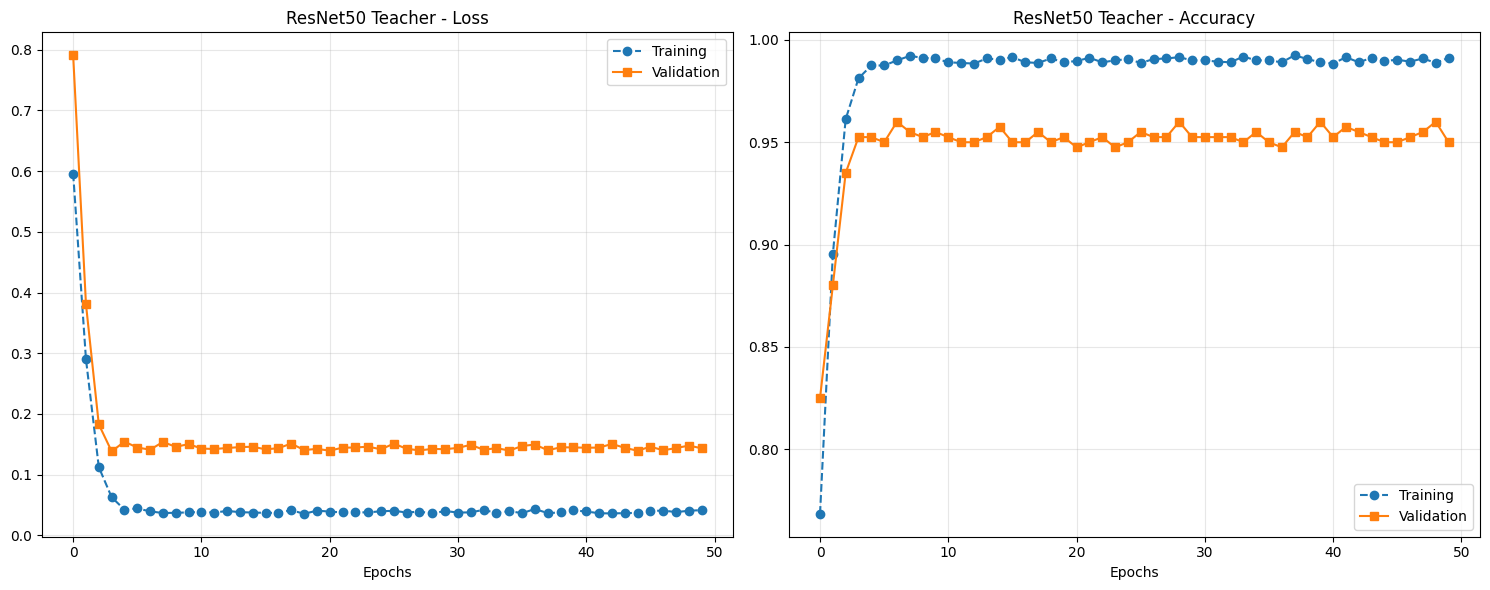


Entraînement terminé. Meilleure précision Validation : 0.9600


In [4]:
# --- 1. INITIALISATION DU MODÈLE ---
# On utilise ResNet50 comme Maître
teacher_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Adaptation de la dernière couche au nombre de classes (OUT_SIZE)
teacher_model.fc = nn.Linear(teacher_model.fc.in_features, OUT_SIZE)
teacher_model = teacher_model.to(device)

# --- 2. PRÉPARATION À LA DISTILLATION (HOOKS) ---
# On attache l'espion à la 'layer4' pour capturer les caractéristiques
teacher_model.layer4.register_forward_hook(get_features('feat', t_features))

# --- 3. CONFIGURATION DE L'ENTRAÎNEMENT ---
# On utilise les paramètres spécifiques
TEACHER_LR = 0.1

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(teacher_model.parameters(), lr=TEACHER_LR, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

# --- 4. BOUCLE D'ENTRAÎNEMENT DU TEACHER ---
best_teacher_wts = deepcopy(teacher_model.state_dict())
best_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de l'entraînement du modèle Père (ResNet50)...")

for epoch in range(1, EPOCHS + 1):
    # Phase d'entraînement
    teacher_model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = teacher_model(inputs) # L'espion capture les caractéristiques ici
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_data)
    epoch_acc = running_corrects.double() / len(train_data)

    # Phase de validation
    teacher_model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = teacher_model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_data)
    val_epoch_acc = val_corrects.double() / len(val_data)

    # Sauvegarde des scores
    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc.item())
    history["val_loss"].append(val_epoch_loss)
    history["val_acc"].append(val_epoch_acc.item())

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")

    # Sauvegarde du meilleur modèle
    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_teacher_wts = deepcopy(teacher_model.state_dict())

    scheduler.step()

# Chargement des meilleurs poids et passage en mode évaluation finale
teacher_model.load_state_dict(best_teacher_wts)
teacher_model.eval()

# Visualisation (Utilise la fonction de la Cellule 2)
plot_training_history(history["train_loss"], history["val_loss"],
                      history["train_acc"], history["val_acc"], title="ResNet50 Teacher")

print(f"\nEntraînement terminé. Meilleure précision Validation : {best_acc:.4f}")

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

# Student Model Setup and Training (Logits Distillation)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/alex.tsan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 97.0MB/s]


Début de la Distillation : Méthode LOGITS (Réponse finale)
Epoch 1/50 | Loss: 0.9599 | Train Acc: 0.8869 | Val Acc: 0.9200
Epoch 2/50 | Loss: 0.4759 | Train Acc: 0.9416 | Val Acc: 0.9350
Epoch 3/50 | Loss: 0.3151 | Train Acc: 0.9669 | Val Acc: 0.9625
Epoch 4/50 | Loss: 0.2272 | Train Acc: 0.9822 | Val Acc: 0.9525
Epoch 5/50 | Loss: 0.2041 | Train Acc: 0.9825 | Val Acc: 0.9600
Epoch 6/50 | Loss: 0.2023 | Train Acc: 0.9856 | Val Acc: 0.9625
Epoch 7/50 | Loss: 0.1523 | Train Acc: 0.9903 | Val Acc: 0.9750
Epoch 8/50 | Loss: 0.1690 | Train Acc: 0.9881 | Val Acc: 0.9550
Epoch 9/50 | Loss: 0.1364 | Train Acc: 0.9894 | Val Acc: 0.9475
Epoch 10/50 | Loss: 0.1219 | Train Acc: 0.9916 | Val Acc: 0.9675
Epoch 11/50 | Loss: 0.0952 | Train Acc: 0.9956 | Val Acc: 0.9725
Epoch 12/50 | Loss: 0.0866 | Train Acc: 0.9941 | Val Acc: 0.9775
Epoch 13/50 | Loss: 0.0958 | Train Acc: 0.9941 | Val Acc: 0.9775
Epoch 14/50 | Loss: 0.0793 | Train Acc: 0.9956 | Val Acc: 0.9725
Epoch 15/50 | Loss: 0.0858 | Train Acc: 

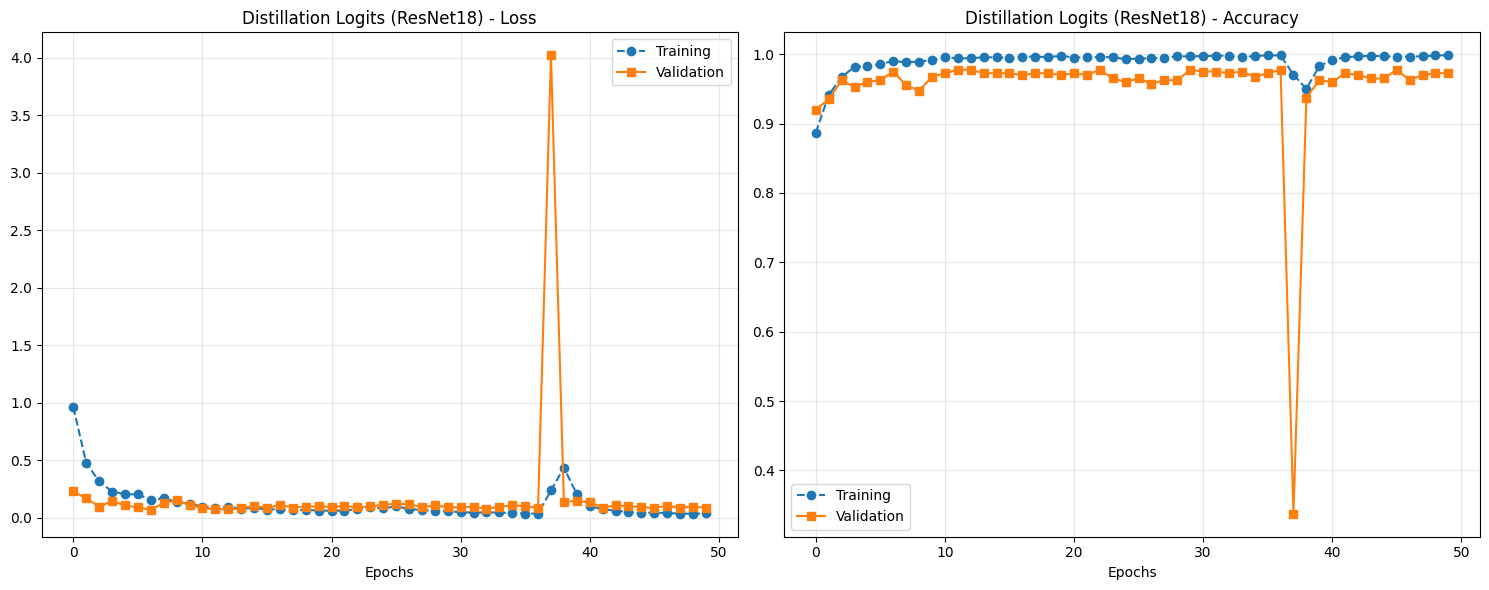

In [6]:
# --- 1. INITIALISATION DE L'ÉLÈVE ---
# On utilise ResNet18. Note : weights=None si tu veux partir de zéro,
# ou ResNet18_Weights.IMAGENET1K_V1 pour du transfert learning.
student_logits = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_logits.fc = nn.Linear(student_logits.fc.in_features, OUT_SIZE)
student_logits = student_logits.to(device)

# --- 2. CONFIGURATION ---
# On utilise l'Adam avec le LR spécifique à la distillation
optimizer_logits = torch.optim.Adam(student_logits.parameters(), lr=0.001)

# Historique pour le graphique final
history_logits = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de la Distillation : Méthode LOGITS (Réponse finale)")

# --- 3. BOUCLE D'ENTRAÎNEMENT ---
for epoch in range(1, EPOCHS + 1):
    student_logits.train()
    teacher_model.eval() # Le maître est figé

    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        # A. Sortie du Maître (Logits bruts, pas de gradients)
        with torch.no_grad():
            # .model si tu as gardé le wrapper, ou juste teacher_model si on a nettoyé
            t_logits = teacher_model(inputs)

        # B. Sortie de l'Élève
        optimizer_logits.zero_grad()
        s_logits = student_logits(inputs)

        # C. Calcul de la Perte (Utilise la fonction de la Cellule 2)
        # On passe : s_logits, t_logits, labels, Température, Alpha
        loss = loss_kd_logits(s_logits, t_logits, labels, T=TEMPERATURE, alpha=0.7)

        loss.backward()
        optimizer_logits.step()

        # Métriques
        _, preds = torch.max(s_logits, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    # --- 4. PHASE DE VALIDATION ---
    student_logits.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_logits(inputs)
            loss_v = F.cross_entropy(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss_v.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    # Calcul des moyennes par époque
    epoch_loss = running_loss / len(train_data)
    epoch_acc = running_corrects.double() / len(train_data)
    val_epoch_loss = val_loss / len(val_data)
    val_epoch_acc = val_corrects.double() / len(val_data)

    history_logits["train_loss"].append(epoch_loss)
    history_logits["train_acc"].append(epoch_acc.item())
    history_logits["val_loss"].append(val_epoch_loss)
    history_logits["val_acc"].append(val_epoch_acc.item())

    print(f"Epoch {epoch}/{EPOCHS} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")

# --- 5. VISUALISATION ---
plot_training_history(history_logits["train_loss"], history_logits["val_loss"],
                      history_logits["train_acc"], history_logits["val_acc"],
                      title="Distillation Logits (ResNet18)")

# Student Model Setup and training (Attention Transfer)

Début de la Distillation : Méthode ATTENTION (Cartes de chaleur)
Epoch 1/50 | Loss: 0.5207 | Val Acc: 0.9000
Epoch 2/50 | Loss: 0.2395 | Val Acc: 0.6450
Epoch 3/50 | Loss: 0.2034 | Val Acc: 0.9450
Epoch 4/50 | Loss: 0.1336 | Val Acc: 0.8925
Epoch 5/50 | Loss: 0.1527 | Val Acc: 0.8825
Epoch 6/50 | Loss: 0.1147 | Val Acc: 0.8450
Epoch 7/50 | Loss: 0.0902 | Val Acc: 0.9675
Epoch 8/50 | Loss: 0.0740 | Val Acc: 0.9475
Epoch 9/50 | Loss: 0.0579 | Val Acc: 0.9600
Epoch 10/50 | Loss: 0.0491 | Val Acc: 0.9450
Epoch 11/50 | Loss: 0.0486 | Val Acc: 0.9350
Epoch 12/50 | Loss: 0.0943 | Val Acc: 0.8875
Epoch 13/50 | Loss: 0.1235 | Val Acc: 0.9300
Epoch 14/50 | Loss: 0.0656 | Val Acc: 0.9600
Epoch 15/50 | Loss: 0.0363 | Val Acc: 0.9550
Epoch 16/50 | Loss: 0.0345 | Val Acc: 0.9650
Epoch 17/50 | Loss: 0.0383 | Val Acc: 0.9650
Epoch 18/50 | Loss: 0.0806 | Val Acc: 0.9375
Epoch 19/50 | Loss: 0.0929 | Val Acc: 0.9575
Epoch 20/50 | Loss: 0.0497 | Val Acc: 0.9550
Epoch 21/50 | Loss: 0.0300 | Val Acc: 0.9500

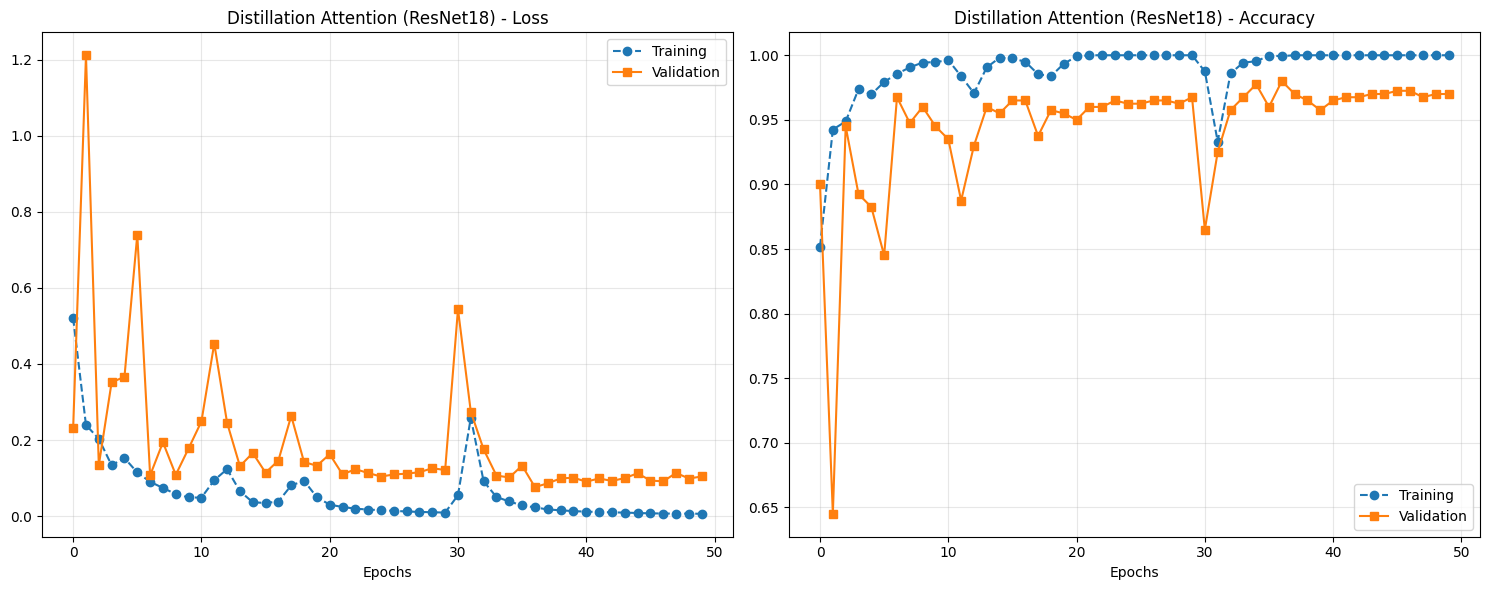

In [7]:
# --- 1. INITIALISATION DE L'ÉLÈVE ---
student_attention = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_attention.fc = nn.Linear(student_attention.fc.in_features, OUT_SIZE)
student_attention = student_attention.to(device)

# --- 2. ACTIVATION DES ESPIONS (HOOKS) ---
# On attache l'espion sur la layer4 de l'élève.
# (Le maître a déjà son espion activé depuis la Cellule 4)
student_attention.layer4.register_forward_hook(get_features('feat', s_features))

# --- 3. CONFIGURATION ---
optimizer_attention = torch.optim.Adam(student_attention.parameters(), lr=0.001)
history_attention = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de la Distillation : Méthode ATTENTION (Cartes de chaleur)")

# --- 4. BOUCLE D'ENTRAÎNEMENT ---
for epoch in range(1, EPOCHS + 1):
    student_attention.train()
    teacher_model.eval()

    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        # A. Passage du Maître -> t_features['feat'] se remplit tout seul
        with torch.no_grad():
            _ = teacher_model(inputs)

        # B. Passage de l'Élève -> s_features['feat'] se remplit tout seul
        optimizer_attention.zero_grad()
        s_logits = student_attention(inputs)

        # C. CALCUL DE LA PERTE HYBRIDE
        # Perte classique (Réalité)
        loss_ce = F.cross_entropy(s_logits, labels)

        # Perte d'Attention (Copie du Maître)
        # On compare les cartes de caractéristiques capturées par les hooks
        loss_at = loss_attention(s_features['feat'], t_features['feat'])

        # Total : on donne souvent un gros poids (beta) à l'attention, ici 10.0
        loss = loss_ce + (10.0 * loss_at)

        loss.backward()
        optimizer_attention.step()

        _, preds = torch.max(s_logits, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    # --- 5. PHASE DE VALIDATION ---
    student_attention.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_attention(inputs)
            loss_v = F.cross_entropy(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss_v.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    # Historique
    history_attention["train_loss"].append(running_loss / len(train_data))
    history_attention["train_acc"].append(running_corrects.double().item() / len(train_data))
    history_attention["val_loss"].append(val_loss / len(val_data))
    history_attention["val_acc"].append(val_corrects.double().item() / len(val_data))

    print(f"Epoch {epoch}/{EPOCHS} | Loss: {history_attention['train_loss'][-1]:.4f} | Val Acc: {history_attention['val_acc'][-1]:.4f}")

# --- 6. VISUALISATION ---
plot_training_history(history_attention["train_loss"], history_attention["val_loss"],
                      history_attention["train_acc"], history_attention["val_acc"],
                      title="Distillation Attention (ResNet18)")

# Student Model Setup and training (Feature Matching)

Début de la Distillation : Méthode FEATURES (Textures et Formes)
Epoch 1/50 | Train Acc: 0.8659 | Val Acc: 0.8625
Epoch 2/50 | Train Acc: 0.9347 | Val Acc: 0.9275
Epoch 3/50 | Train Acc: 0.9547 | Val Acc: 0.8575
Epoch 4/50 | Train Acc: 0.9609 | Val Acc: 0.8700
Epoch 5/50 | Train Acc: 0.9816 | Val Acc: 0.9375
Epoch 6/50 | Train Acc: 0.9809 | Val Acc: 0.9250
Epoch 7/50 | Train Acc: 0.9878 | Val Acc: 0.9350
Epoch 8/50 | Train Acc: 0.9897 | Val Acc: 0.9475
Epoch 9/50 | Train Acc: 0.9981 | Val Acc: 0.9725
Epoch 10/50 | Train Acc: 0.9906 | Val Acc: 0.9175
Epoch 11/50 | Train Acc: 0.9850 | Val Acc: 0.9625
Epoch 12/50 | Train Acc: 0.9856 | Val Acc: 0.8975
Epoch 13/50 | Train Acc: 0.9978 | Val Acc: 0.9725
Epoch 14/50 | Train Acc: 0.9984 | Val Acc: 0.9550
Epoch 15/50 | Train Acc: 0.9962 | Val Acc: 0.9600
Epoch 16/50 | Train Acc: 0.9956 | Val Acc: 0.9700
Epoch 17/50 | Train Acc: 0.9831 | Val Acc: 0.9400
Epoch 18/50 | Train Acc: 0.9878 | Val Acc: 0.9450
Epoch 19/50 | Train Acc: 0.9984 | Val Acc: 0

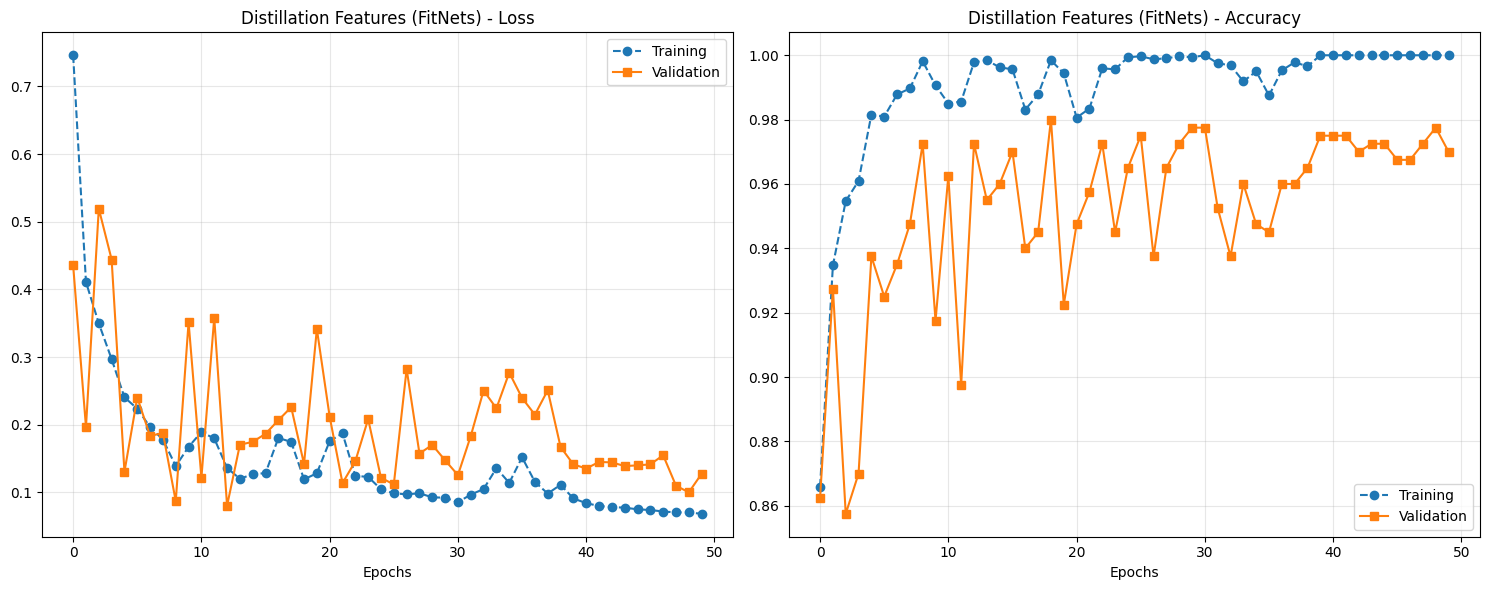

In [8]:
# --- 1. INITIALISATION L'ÉLÈVE ET DU PROJECTEUR ---
student_features_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_features_model.fc = nn.Linear(student_features_model.fc.in_features, OUT_SIZE)
student_features_model = student_features_model.to(device)

# Le projecteur permet de passer de 512 à 2048 canaux pour comparer l'élève au maître
projector = FeatureLoss(s_channels=512, t_channels=2048).to(device)

# --- 2. ACTIVATION DES ESPIONS ---
student_features_model.layer4.register_forward_hook(get_features('feat', s_features))

# --- 3. CONFIGURATION ---
# On ajoute les paramètres du projecteur à l'optimiseur pour qu'il apprenne aussi l'alignement
optimizer_feat = torch.optim.Adam(
    list(student_features_model.parameters()) + list(projector.parameters()),
    lr=0.001
)
history_feat = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de la Distillation : Méthode FEATURES (Textures et Formes)")

# --- 4. BOUCLE D'ENTRAÎNEMENT ---
for epoch in range(1, EPOCHS + 1):
    student_features_model.train()
    teacher_model.eval()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        # A. Passage du Maître
        with torch.no_grad():
            _ = teacher_model(inputs)

        # B. Passage de l'Élève
        optimizer_feat.zero_grad()
        s_logits = student_features_model(inputs)

        # C. CALCUL DE LA PERTE
        loss_ce = F.cross_entropy(s_logits, labels)

        # Comparaison des caractéristiques via le projecteur
        loss_f = projector(s_features['feat'], t_features['feat'])
        loss = loss_ce + (1.0 * loss_f)

        loss.backward()
        optimizer_feat.step()

        _, preds = torch.max(s_logits, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    # --- 5. PHASE DE VALIDATION ---
    student_features_model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_features_model(inputs)

            v_loss = F.cross_entropy(outputs, labels) # Perte de validation simple
            val_loss += v_loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    # Enregistrement des 4 métriques pour un affichage complet
    history_feat["train_loss"].append(running_loss / len(train_data))
    history_feat["val_loss"].append(val_loss / len(val_data))
    history_feat["train_acc"].append(running_corrects.double().item() / len(train_data))
    history_feat["val_acc"].append(val_corrects.double().item() / len(val_data))

    print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {history_feat['train_acc'][-1]:.4f} | Val Acc: {history_feat['val_acc'][-1]:.4f}")

# --- 6. VISUALISATION CORRIGÉE ---
# On passe désormais les 4 listes distinctes
plot_training_history(history_feat["train_loss"], history_feat["val_loss"],
                      history_feat["train_acc"], history_feat["val_acc"],
                      title="Distillation Features (FitNets)")

# Student Model Setup and training (Relation Based)

Starting Relational Knowledge Distillation (RKD)...
Epoch 1 | Train Acc: 0.8594 | Val Acc: 0.8850
Epoch 2 | Train Acc: 0.9450 | Val Acc: 0.9200
Epoch 3 | Train Acc: 0.9684 | Val Acc: 0.9350
Epoch 4 | Train Acc: 0.9738 | Val Acc: 0.9450
Epoch 5 | Train Acc: 0.9847 | Val Acc: 0.9300
Epoch 6 | Train Acc: 0.9838 | Val Acc: 0.9050
Epoch 7 | Train Acc: 0.9944 | Val Acc: 0.9700
Epoch 8 | Train Acc: 0.9975 | Val Acc: 0.9750
Epoch 9 | Train Acc: 0.9997 | Val Acc: 0.9575
Epoch 10 | Train Acc: 1.0000 | Val Acc: 0.9625
Epoch 11 | Train Acc: 1.0000 | Val Acc: 0.9700
Epoch 12 | Train Acc: 1.0000 | Val Acc: 0.9650
Epoch 13 | Train Acc: 1.0000 | Val Acc: 0.9600
Epoch 14 | Train Acc: 1.0000 | Val Acc: 0.9675
Epoch 15 | Train Acc: 1.0000 | Val Acc: 0.9675
Epoch 16 | Train Acc: 0.9997 | Val Acc: 0.9625
Epoch 17 | Train Acc: 0.9988 | Val Acc: 0.9225
Epoch 18 | Train Acc: 0.9175 | Val Acc: 0.8725
Epoch 19 | Train Acc: 0.9472 | Val Acc: 0.9325
Epoch 20 | Train Acc: 0.9859 | Val Acc: 0.9475
Epoch 21 | Train 

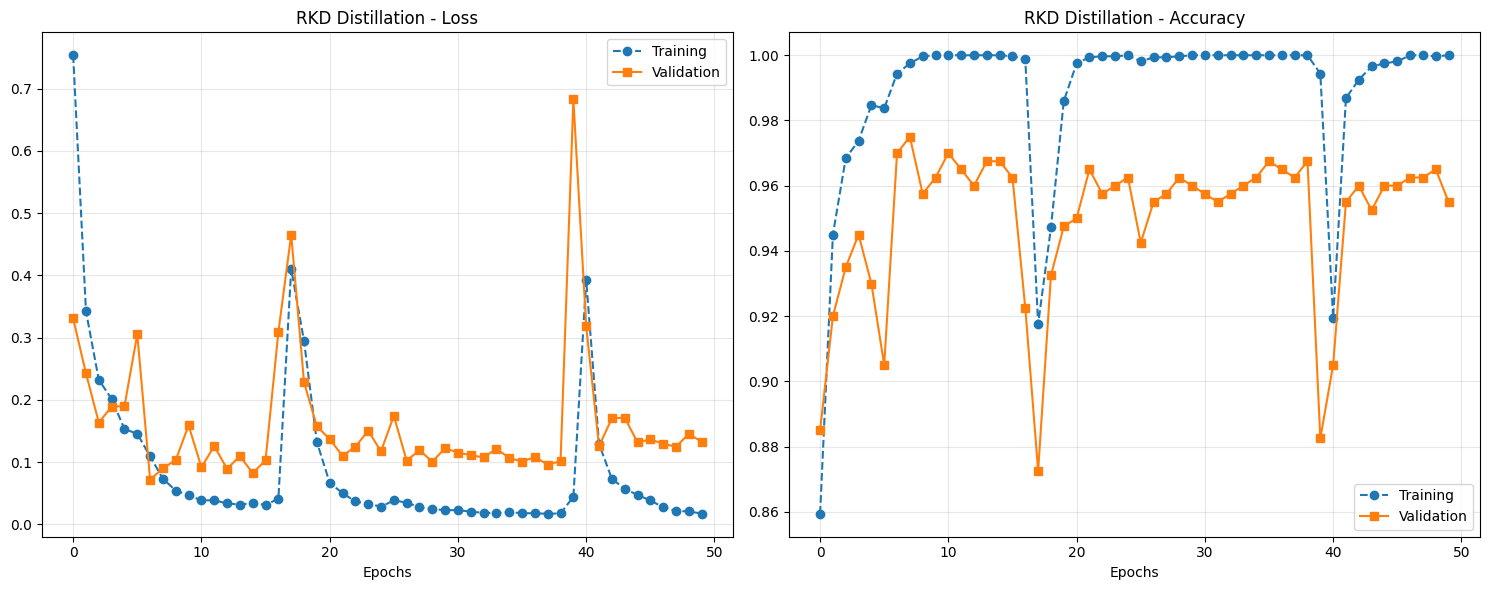

In [9]:
# --- 1. RÉ-INITIALISATION SÉCURISÉE DES DICTIONNAIRES ---
# On s'assure que les dictionnaires existent et sont vides
t_features, s_features = {}, {}

# --- 2. INITIALISATION DE L'ÉLÈVE ---
student_relational = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_relational.fc = nn.Linear(student_relational.fc.in_features, OUT_SIZE)
student_relational = student_relational.to(device)

# --- 3. ATTACHEMENT FORCÉ DES ESPIONS (POUR ÉVITER LE KEYERROR) ---
# On remet les espions sur le Maître ET l'Élève juste avant la boucle
teacher_model.layer4.register_forward_hook(get_features('feat', t_features))
student_relational.layer4.register_forward_hook(get_features('feat', s_features))

# 3. Configuration
optimizer_relational = torch.optim.Adam(student_relational.parameters(), lr=0.001)
history_relational = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("Starting Relational Knowledge Distillation (RKD)...")

# --- 4. CONFIGURATION ---
for epoch in range(1, EPOCHS + 1):
    student_relational.train()
    teacher_model.eval()
    running_loss, running_corrects = 0.0, 0

    for data, target in train_dl:
        data, target = data.to(device), target.to(device)
        optimizer_relational.zero_grad()

        # A. Passage du Maître (Remplit t_features['feat'])
        with torch.no_grad():
            _ = teacher_model(data)

        # B. Passage de l'Élève (Remplit s_features['feat'])
        outputs = student_relational(data)

        # C. CALCUL DE LA PERTE (combinée)
        loss_ce = F.cross_entropy(outputs, target)

        # On utilise la fonction de distance RKD (Cellule 2)
        loss_rkd = loss_rkd_distance(s_features['feat'], t_features['feat'])

        # Poids RKD (25.0 est la valeur recommandée par le papier original)
        loss = loss_ce + (25.0 * loss_rkd)

        loss.backward()
        optimizer_relational.step()

        running_loss += loss.item() * data.size(0)
        running_corrects += torch.sum(outputs.argmax(1) == target)

    # --- 6. PHASE DE VALIDATION ---
    student_relational.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for data, target in val_dl:
            data, target = data.to(device), target.to(device)
            outputs = student_relational(data)
            v_loss = F.cross_entropy(outputs, target)
            val_loss += v_loss.item() * data.size(0)
            val_corrects += torch.sum(outputs.argmax(1) == target)

    # Historique pour l'affichage
    history_relational["train_loss"].append(running_loss / len(train_data))
    history_relational["val_loss"].append(val_loss / len(val_data))
    history_relational["train_acc"].append(running_corrects.double().item() / len(train_data))
    history_relational["val_acc"].append(val_corrects.double().item() / len(val_data))

    print(f"Epoch {epoch} | Train Acc: {history_relational['train_acc'][-1]:.4f} | Val Acc: {history_relational['val_acc'][-1]:.4f}")

# --- 7. VISUALISATION ---
plot_training_history(history_relational["train_loss"], history_relational["val_loss"],
                      history_relational["train_acc"], history_relational["val_acc"],
                      title="RKD Distillation")

# Selector

In [10]:
# --- CHOISIS TA MÉTHODE ICI ---
# Options : "logits", "attention", "features", "rkd"
METHODE = "rkd"

print(f"Mode sélectionné : {METHODE.upper()}")

# 1. Init Student
final_student = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(device)
final_student.fc = nn.Linear(final_student.fc.in_features, OUT_SIZE).to(device)

# On s'assure que les dictionnaires sont prêts pour les hooks
t_features, s_features = {}, {}
# On attache l'espion (hook) pour les méthodes qui en ont besoin (attention, features, rkd)
teacher_model.layer4.register_forward_hook(get_features('feat', t_features))
final_student.layer4.register_forward_hook(get_features('feat', s_features))

# 2. Init Projector (seulement si besoin pour 'features')
proj = FeatureLoss(512, 2048).to(device) if METHODE == "features" else None

# 3. Optimizer
params = list(final_student.parameters()) + (list(proj.parameters()) if proj else [])
opt = torch.optim.Adam(params, lr=0.001)

# 4. Boucle d'entraînement simplifiée
for epoch in range(1, 4): # On fait 3 époques pour tester
    final_student.train()
    for img, lbl in train_dl:
        img, lbl = img.to(device), lbl.to(device)

        # Passage du maître
        with torch.no_grad():
            t_out = teacher_model(img)

        # Passage de l'élève
        s_out = final_student(img)

        # Sélection de la logique de perte
        if METHODE == "logits":
            loss = loss_kd_logits(s_out, t_out, lbl)

        elif METHODE == "attention":
            loss = F.cross_entropy(s_out, lbl) + 10.0 * loss_attention(s_features['feat'], t_features['feat'])

        elif METHODE == "features":
            loss = F.cross_entropy(s_out, lbl) + proj(s_features['feat'], t_features['feat'])

        elif METHODE == "rkd":
            # Utilisation de la perte relationnelle (RKD) définie en Cellule 2
            loss = F.cross_entropy(s_out, lbl) + 25.0 * loss_rkd_distance(s_features['feat'], t_features['feat'])

        opt.zero_grad()
        loss.backward()
        opt.step()

    print(f"Époque {epoch} terminée.")

Mode sélectionné : RKD
Époque 1 terminée.
Époque 2 terminée.
Époque 3 terminée.


# Model Evaluation & Inference

Évaluation de Maître (ResNet50) en cours...

--- Maître (ResNet50) : Rapport de Classification ---
              precision    recall  f1-score   support

      glioma       0.97      1.00      0.98        97
  meningioma       0.99      0.93      0.96       112
     notumor       0.98      0.99      0.99       104
   pituitary       0.97      1.00      0.98        87

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



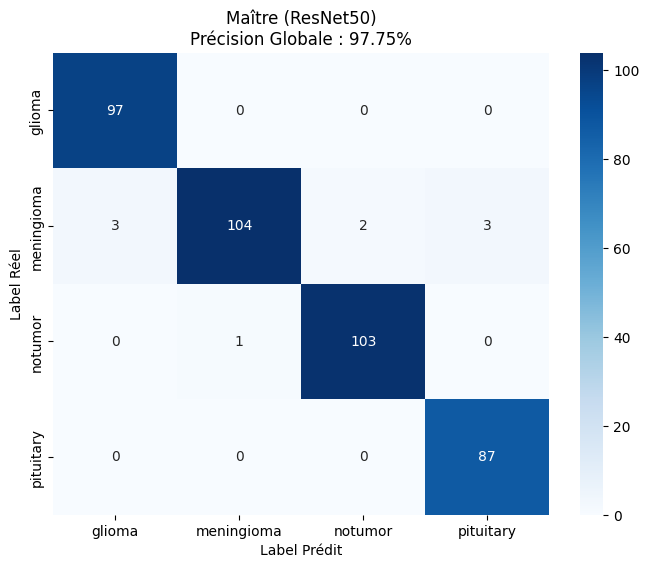

Évaluation de Élève Logits (ResNet18) en cours...

--- Élève Logits (ResNet18) : Rapport de Classification ---
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.98        97
  meningioma       0.98      0.96      0.97       112
     notumor       0.98      1.00      0.99       104
   pituitary       0.98      1.00      0.99        87

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



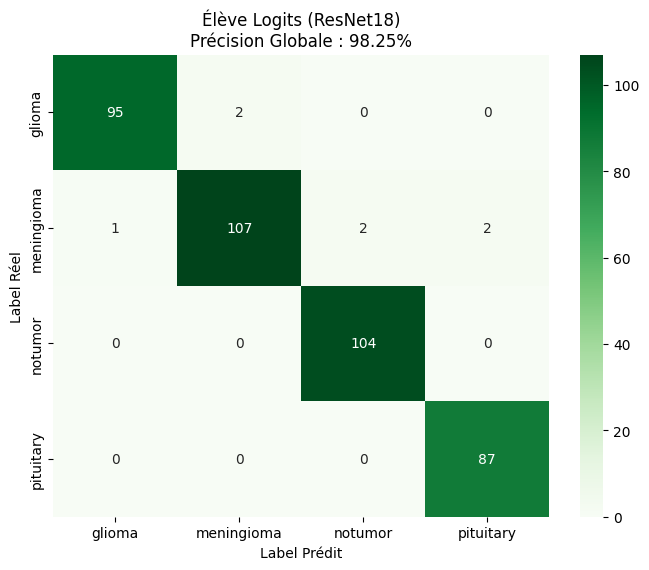

Évaluation de Élève Attention (ResNet18) en cours...

--- Élève Attention (ResNet18) : Rapport de Classification ---
              precision    recall  f1-score   support

      glioma       0.97      1.00      0.98        97
  meningioma       0.98      0.96      0.97       112
     notumor       0.98      0.99      0.99       104
   pituitary       1.00      0.99      0.99        87

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



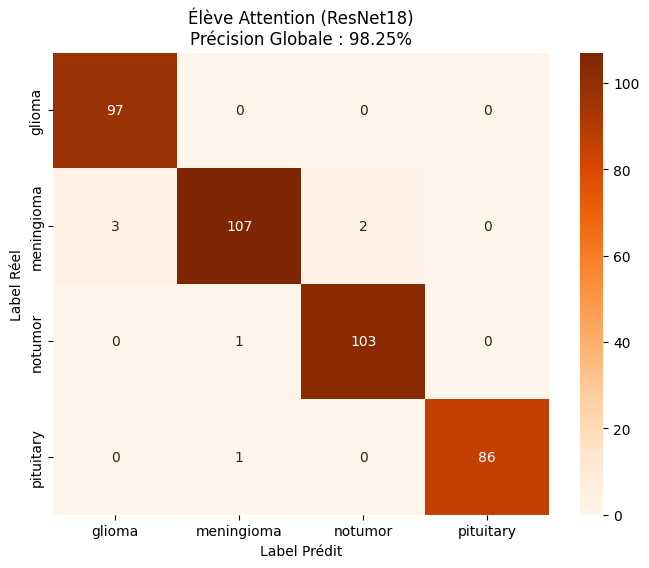

Évaluation de Élève Features (ResNet18) en cours...

--- Élève Features (ResNet18) : Rapport de Classification ---
              precision    recall  f1-score   support

      glioma       0.97      1.00      0.98        97
  meningioma       1.00      0.92      0.96       112
     notumor       0.97      1.00      0.99       104
   pituitary       0.97      1.00      0.98        87

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



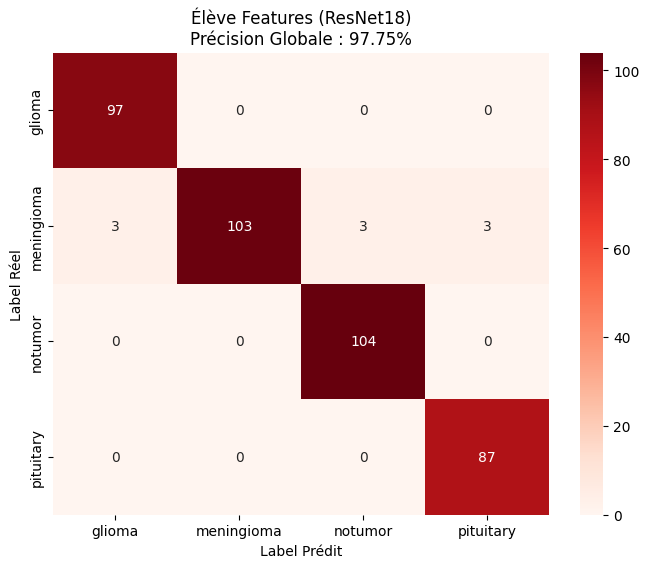

Évaluation de Élève Relationnel (ResNet18) en cours...

--- Élève Relationnel (ResNet18) : Rapport de Classification ---
              precision    recall  f1-score   support

      glioma       0.97      0.98      0.97        97
  meningioma       0.98      0.92      0.95       112
     notumor       0.96      0.99      0.98       104
   pituitary       0.97      1.00      0.98        87

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



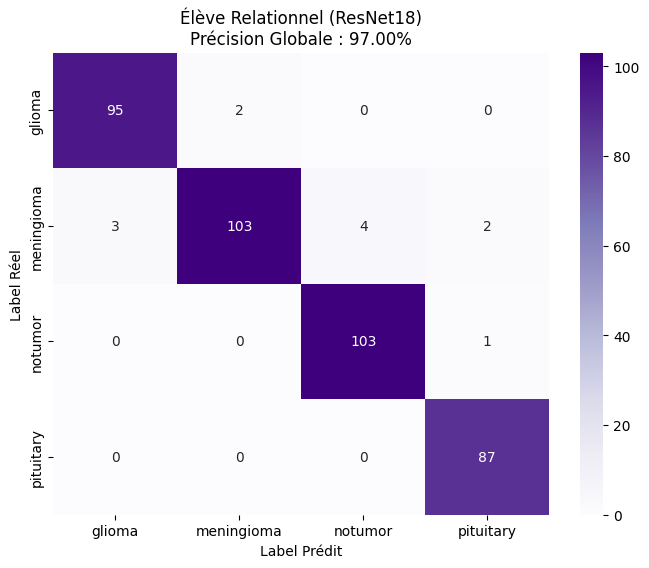

In [11]:
# --- 1. FONCTION D'ÉVALUATION GÉNÉRIQUE ---
def evaluate_model(model, dataloader, title="Model Evaluation", color="Blues"):
    """
    Évalue un modèle sur un dataloader, affiche le rapport et la matrice de confusion.
    """
    model.eval()
    all_preds = []
    all_truth = []

    print(f"Évaluation de {title} en cours...")

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_truth.extend(labels.numpy())

    # Calcul des métriques
    score = accuracy_score(all_truth, all_preds)
    label_names = [index_label[i] for i in range(OUT_SIZE)]

    # Affichage du rapport
    print(f"\n--- {title} : Rapport de Classification ---")
    print(classification_report(all_truth, all_preds, target_names=label_names))

    # Affichage de la Matrice de Confusion
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(all_truth, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{title}\nPrécision Globale : {score:.2%}")
    plt.ylabel('Label Réel')
    plt.xlabel('Label Prédit')
    plt.show()

    return score

# --- 2. LANCEMENT DES ÉVALUATIONS ---

# 1. On évalue le Maître (Référence)
score_t = evaluate_model(teacher_model, test_dl, title="Maître (ResNet50)", color="Blues")

# 2. On évalue l'Élève Logits (Cellule 5)
if 'student_logits' in locals():
    score_s_logits = evaluate_model(student_logits, test_dl, title="Élève Logits (ResNet18)", color="Greens")

# 3. On évalue l'Élève Attention (Cellule 6)
if 'student_attention' in locals():
    score_s_at = evaluate_model(student_attention, test_dl, title="Élève Attention (ResNet18)", color="Oranges")

# 4. On évalue l'Élève Features (Cellule 7)
if 'student_features_model' in locals():
    score_s_feat = evaluate_model(student_features_model, test_dl, title="Élève Features (ResNet18)", color="Reds")

# 5. AJOUT : On évalue l'Élève Relationnel (Cellule 11)
if 'student_relational' in locals():
    score_s_rel = evaluate_model(student_relational, test_dl, title="Élève Relationnel (ResNet18)", color="Purples")

# --- 3. FONCTION DE PRÉDICTION INDIVIDUELLE (Optionnelle) ---
def predict_single_image(img_path, model):
    """Pour tester une seule image à la main"""
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform_pipeline(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(img_tensor)
        prob = F.softmax(out, dim=1)

    pred_idx = out.argmax(1).item()
    confidence = round(prob[0][pred_idx].item() * 100, 2)
    return index_label[pred_idx], confidence

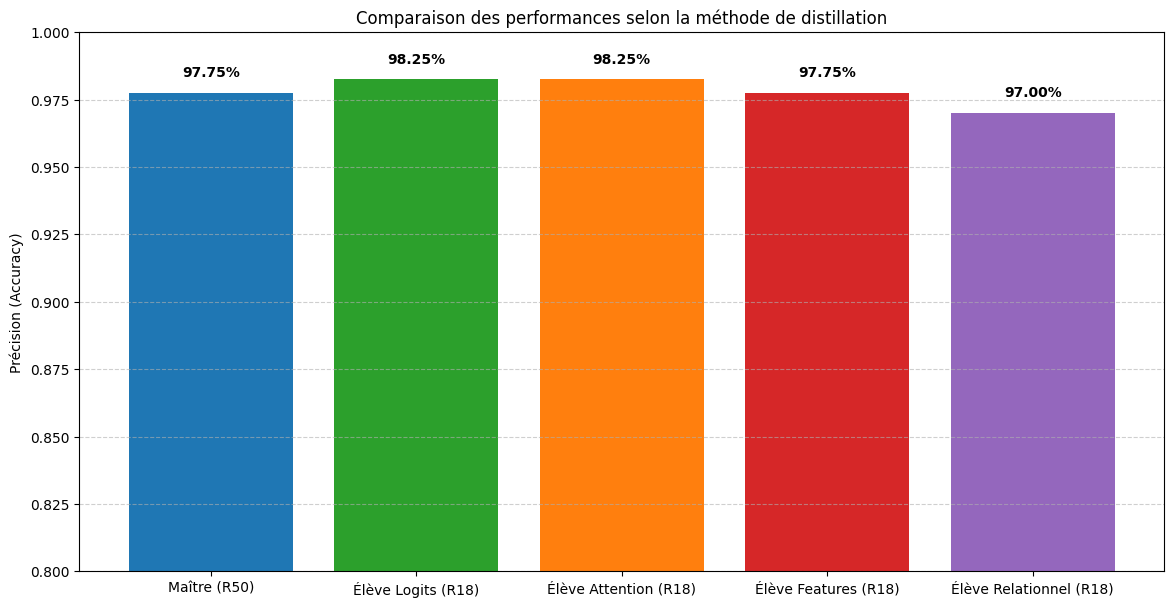

In [12]:
# ATTENTION : nécessaire de lancer la cellule précédente (Évaluation)

# Mettre à jour si nouvelles méthodes
methods = [
    'Maître (R50)',
    'Élève Logits (R18)',
    'Élève Attention (R18)',
    'Élève Features (R18)',
    'Élève Relationnel (R18)'
]

# On regroupe les scores obtenus
# Assure-toi que score_s_rel a été généré dans la cellule d'évaluation
scores = [score_t, score_s_logits, score_s_at, score_s_feat, score_s_rel]

plt.figure(figsize=(14, 7))

# Création du graphique à barres avec une nouvelle couleur pour RKD (violet)
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
bars = plt.bar(methods, scores, color=colors)

# Ajout des valeurs exactes au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.2%}",
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Précision (Accuracy)')
plt.title('Comparaison des performances selon la méthode de distillation')

# On ajuste l'axe Y pour zoomer sur la zone intéressante (ex: de 80% à 100%)
plt.ylim(0.8, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Model                  | Params (M)   | Latency (ms) | FPS       
-----------------------------------------------------------------
Teacher (R50)          | 23.52        | 7.60         | 131.55    
Student Logits (R18)   | 11.18        | 3.08         | 324.82    
Student Attn (R18)     | 11.18        | 3.05         | 327.71    
Student Feat (R18)     | 11.18        | 3.02         | 331.55    
Student Rel (R18)      | 11.18        | 3.12         | 320.05    


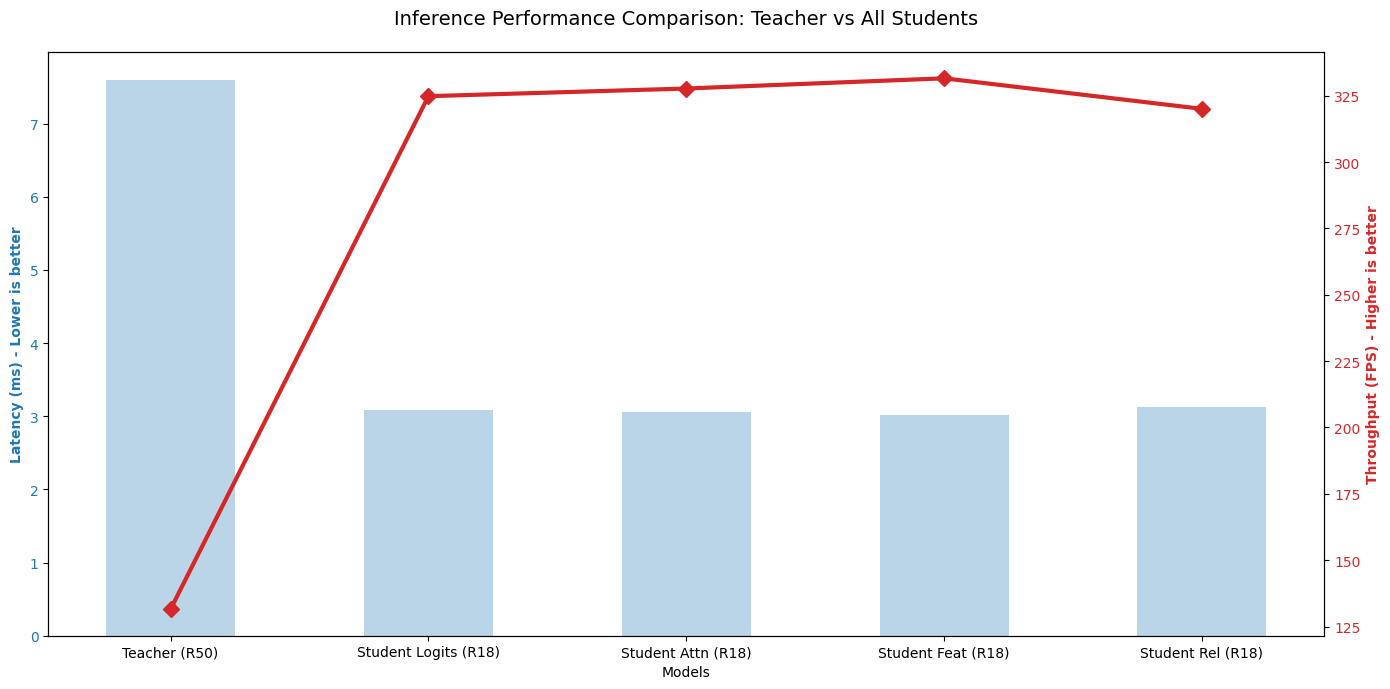

In [13]:
# --- 1. MEASUREMENT FUNCTIONS ---
def count_parameters(model):
    """Counts the number of trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_speed(model, device, input_size=(1, 3, 224, 224), iterations=100):
    """Measures latency (ms) and throughput (FPS)"""
    model.eval()
    dummy_input = torch.randn(*input_size).to(device)

    # Warm-up (initialize CUDA kernels)
    for _ in range(10): _ = model(dummy_input)
    if device == "cuda": torch.cuda.synchronize()

    start_time = time.time()
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
            if device == "cuda": torch.cuda.synchronize()

    total_time = time.time() - start_time
    return (total_time / iterations) * 1000, iterations / total_time

# --- 2. DATA COLLECTION FOR ALL MODELS ---

# Dictionary to store models if they exist in memory
models_to_test = {
    "Teacher (R50)": teacher_model
}

if 'student_logits' in locals():
    models_to_test["Student Logits (R18)"] = student_logits
if 'student_attention' in locals():
    models_to_test["Student Attn (R18)"] = student_attention
if 'student_features_model' in locals():
    models_to_test["Student Feat (R18)"] = student_features_model
if 'student_relational' in locals():
    models_to_test["Student Rel (R18)"] = student_relational

benchmark_results = {}

for name, model in models_to_test.items():
    latency, fps = measure_inference_speed(model, device)
    benchmark_results[name] = {
        "params": count_parameters(model) / 1e6, # In Millions
        "latency": latency,
        "fps": fps
    }

# --- 3. RESULTS TABLE ---
header = f"{'Model':<22} | {'Params (M)':<12} | {'Latency (ms)':<12} | {'FPS':<10}"
print(header)
print("-" * len(header))

for name, res in benchmark_results.items():
    print(f"{name:<22} | {res['params']:<12.2f} | {res['latency']:<12.2f} | {res['fps']:<10.2f}")

# --- 4. GLOBAL VISUALIZATION ---
labels = list(benchmark_results.keys())
latencies = [res["latency"] for res in benchmark_results.values()]
fps_values = [res["fps"] for res in benchmark_results.values()]

fig, ax1 = plt.subplots(figsize=(14, 7))

# Axis 1: Latency (Bars)
color_lat = 'tab:blue'
ax1.set_xlabel('Models')
ax1.set_ylabel('Latency (ms) - Lower is better', color=color_lat, fontweight='bold')
ax1.bar(labels, latencies, color=color_lat, alpha=0.3, width=0.5, label='Latency (ms)')
ax1.tick_params(axis='y', labelcolor=color_lat)

# Axis 2: FPS (Line)
ax2 = ax1.twinx()
color_fps = 'tab:red'
ax2.set_ylabel('Throughput (FPS) - Higher is better', color=color_fps, fontweight='bold')
ax2.plot(labels, fps_values, color=color_fps, marker='D', linewidth=3, markersize=8, label='FPS')
ax2.tick_params(axis='y', labelcolor=color_fps)

plt.title('Inference Performance Comparison: Teacher vs All Students', fontsize=14, pad=20)
fig.tight_layout()
plt.show()